🚀 Starting HVDC Fault Classification with Hierarchical CNN
📁 Step 0: Loading dataset...


Saving HVDC_Dataset.csv to HVDC_Dataset (1).csv
Dataset loaded: HVDC_Dataset (1).csv with shape (6720, 40)
🔍 Validating dataset...
✅ Dataset validation passed. Shape: (6720, 40)

📊 Class Distribution:
Stage1_Label
0     480
1    2400
2    3840
Name: count, dtype: int64

🔧 Step 2: Preparing features...
Using 26 features

🎯 Step 3: Preparing Stage 1 data...
🔄 Augmenting data with factor 1...

🔌 Step 4: Preparing DC fault subtype data...
🔄 Augmenting data with factor 1...

⚡ Step 5: Preparing AC fault subtype data...
🔄 Augmenting data with factor 1...

🏗️  Step 6: Building and training models...

🎯 Training Stage 1 model (No/DC/AC classification)...
🔄 Performing 5-fold cross-validation...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
✅ CV Accuracy: 0.9676 ± 0.0024
Epoch 1/150
135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6153 - loss: 0.7183 - precision: 0.6422 - recall: 0.5805 - val_accuracy: 0.7351 - val_loss: 0.6885 - val_precision: 0.8801 - val_recall: 0.5455 - learn

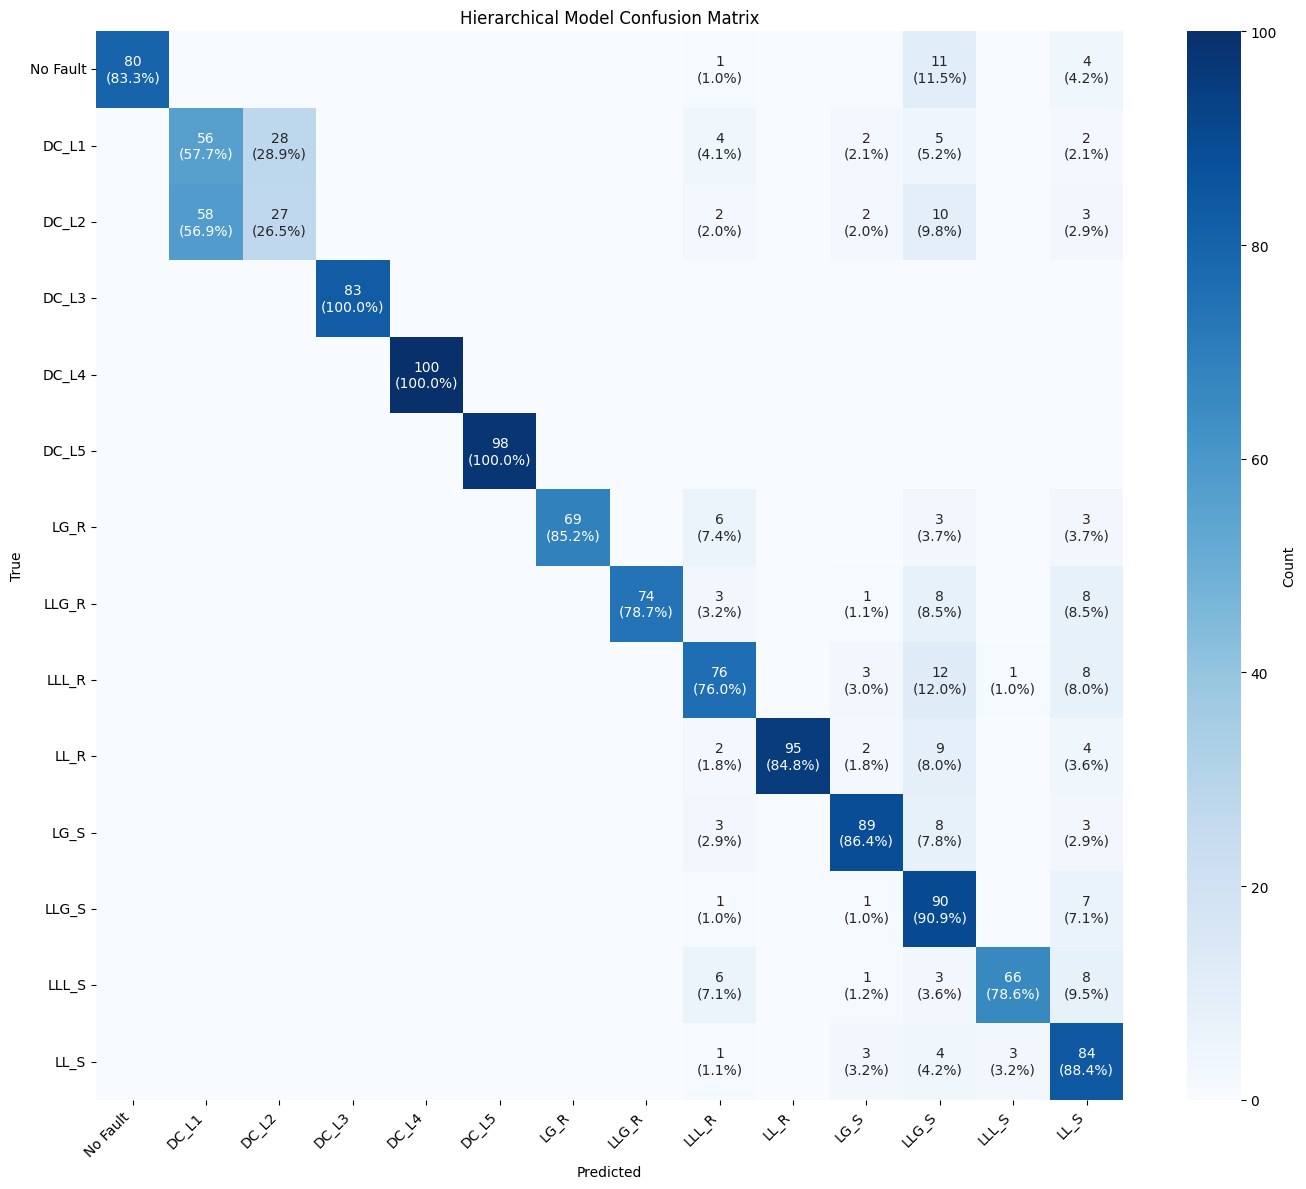

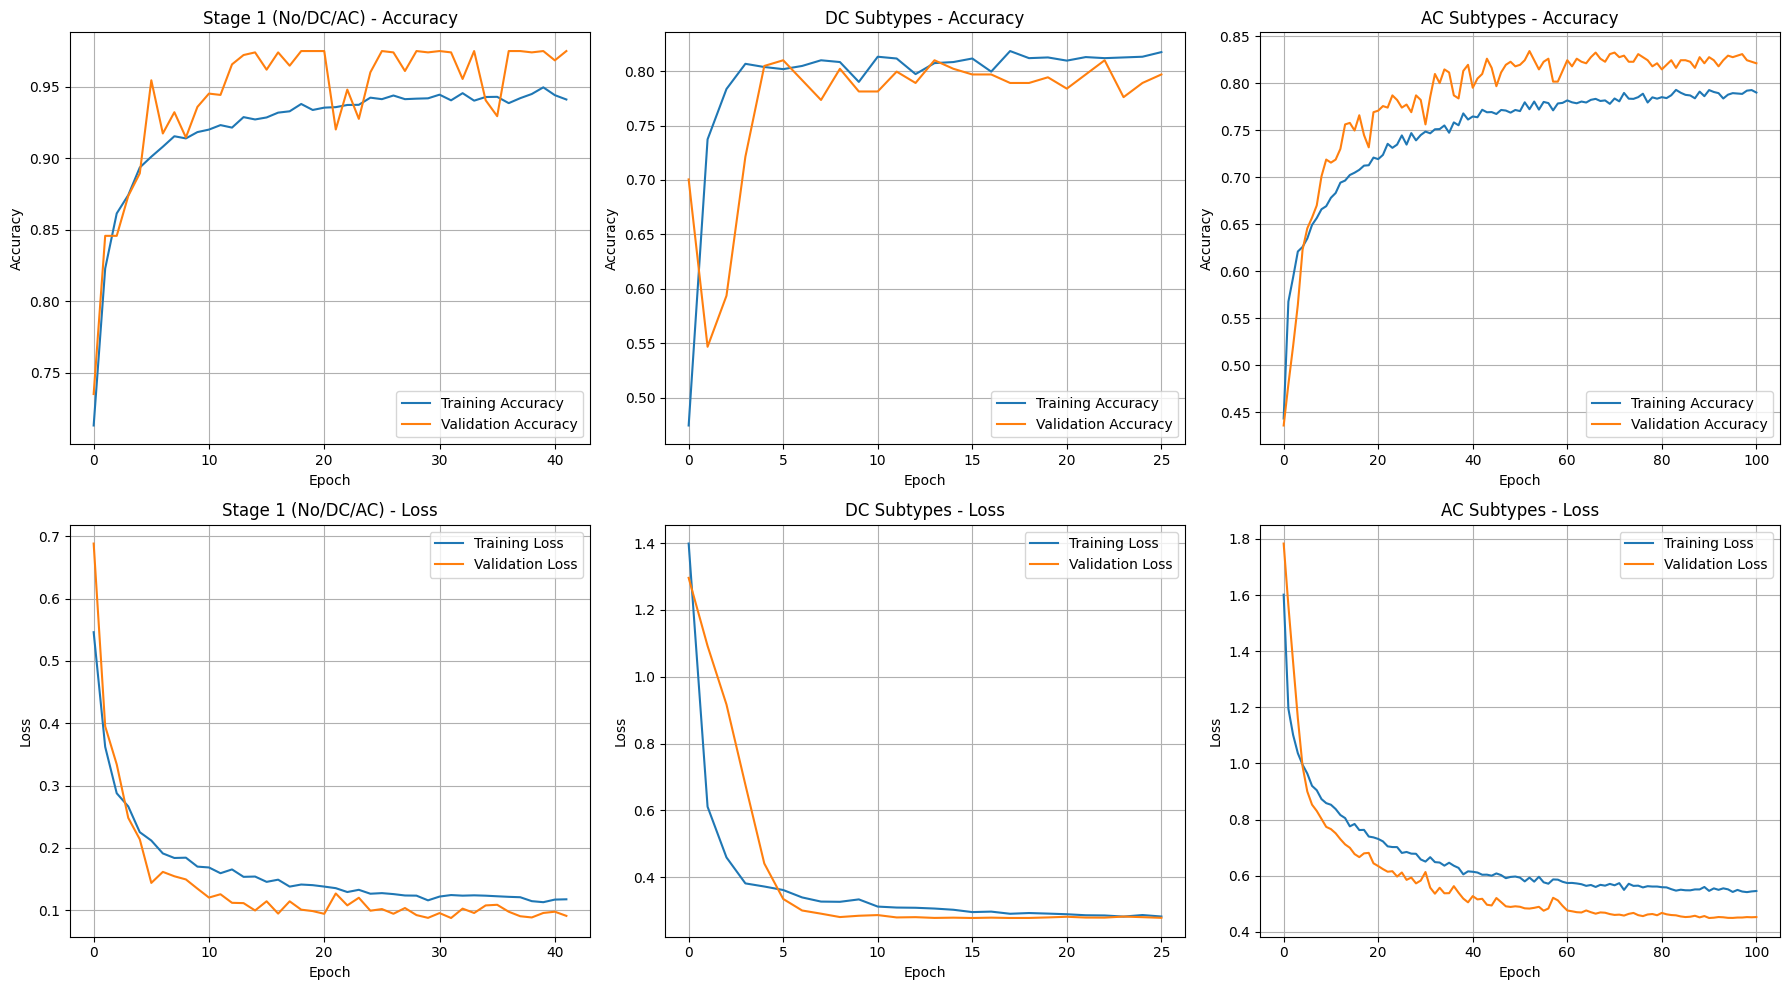

💾 Saving models to models/...
✅ Models and configuration saved successfully!
📊 Results saved to hierarchical_results.csv

🎉 TRAINING COMPLETE!
✅ Overall Hierarchical Model Accuracy: 0.8088
✅ Cohen's Kappa Score: 0.7940
✅ Total samples processed: 6720
✅ Test samples: 1344


In [ ]:
# === HVDC Fault Classification: Hierarchical CNN with Comprehensive Improvements ===

import os
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import files
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, classification_report,
                           accuracy_score, precision_recall_fscore_support,
                           cohen_kappa_score)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense,
                                   Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# === Configuration ===
CONFIG = {
    'model_params': {
        'filters_1': 64,
        'filters_2': 128,
        'dropout_rate': 0.3,
        'learning_rate': 0.0005,
        'batch_size': 64,
        'epochs': 150,
        'dense_units': 128
    },
    'training_params': {
        'test_size': 0.2,
        'validation_size': 0.2,
        'random_state': 42,
        'early_stopping_patience': 10,
        'reduce_lr_patience': 5
    },
    'evaluation_params': {
        'cv_folds': 5,
        'show_confusion_matrix': True,
        'save_results': True
    },
    'augmentation_params': {
        'enable_augmentation': True,
        'augment_factor': 1,
        'noise_std': 0.01
    }
}

# === Data Validation and Error Handling ===
def validate_dataset(df):
    """Validate dataset structure and quality"""
    print("🔍 Validating dataset...")

    dc_columns = ['DC_L1', 'DC_L2', 'DC_L3', 'DC_L4', 'DC_L5']
    ac_fault_cols = ['LG_R', 'LLG_R', 'LLL_R', 'LL_R', 'LG_S', 'LLG_S', 'LLL_S', 'LL_S']
    no_fault_col = ['No Fault']

    required_cols = dc_columns + ac_fault_cols + no_fault_col

    # Filter required_cols based on actual columns in df
    required_cols_in_df = [col for col in required_cols if col in df.columns]
    missing_cols = [col for col in required_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(f"❌ Missing required columns: {missing_cols}")

    # Check for data quality issues
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        print(f"⚠️  Warning: Dataset contains {null_count} null values")
        df = df.fillna(df.mean(numeric_only=True))  # Simple imputation

    # Check class distribution
    print(f"✅ Dataset validation passed. Shape: {df.shape}")
    return df, dc_columns, ac_fault_cols, no_fault_col

def augment_time_series_data(X, y, augment_factor=1, noise_std=0.01):
    """Add noise-based augmentation to increase dataset size"""
    if augment_factor == 0:
        return X, y

    print(f"🔄 Augmenting data with factor {augment_factor}...")
    X_aug = []
    y_aug = []

    for i in range(len(X)):
        # Original sample
        X_aug.append(X[i])
        y_aug.append(y[i])

        # Add augmented versions
        for _ in range(augment_factor):
            # Add small random noise
            noise = np.random.normal(0, noise_std, X[i].shape)
            X_aug.append(X[i] + noise)
            y_aug.append(y[i])

    return np.array(X_aug), np.array(y_aug)

def build_improved_cnn_model(num_classes, input_shape, config):
    """Build improved CNN model with batch normalization and configurable architecture"""
    model = Sequential([
        Conv1D(config['filters_1'], 3, activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(config['dropout_rate']),

        Conv1D(config['filters_2'], 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(config['dropout_rate']),

        Flatten(),
        Dense(config['dense_units'], activation='relu'),
        BatchNormalization(),
        Dropout(config['dropout_rate']),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall']
    )

    return model

def evaluate_with_cv(X, y, model_builder, model_config, training_config, n_folds=5):
    """Evaluate model using cross-validation"""
    print(f"🔄 Performing {n_folds}-fold cross-validation...")
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    cv_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, np.argmax(y, axis=1))):
        print(f"  Fold {fold + 1}/{n_folds}")
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        # Build and train model
        model = model_builder(y.shape[1], X.shape[1:], model_config)

        # Callbacks
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=training_config['early_stopping_patience'] // 2,  # Reduced patience for CV
            restore_best_weights=True,
            verbose=0
        )

        model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=50,  # Reduced epochs for CV
            batch_size=model_config['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Evaluate
        val_loss, val_acc, val_precision, val_recall = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        cv_scores.append(val_acc)

    mean_score = np.mean(cv_scores)
    std_score = np.std(cv_scores)
    print(f"✅ CV Accuracy: {mean_score:.4f} ± {std_score:.4f}")

    return mean_score, std_score

def create_hierarchical_predictions(df_test, models, scaler, feature_columns):
    """Create hierarchical predictions with proper index handling"""
    print("🔮 Creating hierarchical predictions...")

    # Prepare test data
    X_test = df_test[feature_columns].values
    X_test_scaled = scaler.transform(X_test)
    X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

    # Get Stage 1 predictions for all samples
    stage1_preds = models['stage1'].predict(X_test_cnn, verbose=0)

    predictions = []

    # Process each sample individually
    for i, (idx, row) in enumerate(df_test.iterrows()):
        stage1_pred = np.argmax(stage1_preds[i])

        if stage1_pred == 0:  # No fault
            predictions.append(0)
        elif stage1_pred == 1:  # DC fault
            # Get DC subtype prediction
            if models['dc'] is not None:
                dc_pred = models['dc'].predict(X_test_cnn[i:i+1], verbose=0)
                predictions.append(1 + np.argmax(dc_pred))
            else:
                # Handle cases where DC model was not trained (no DC samples)
                # Assign a placeholder or handle as appropriate for your problem
                predictions.append(-1) # Example: -1 indicates unclassifiable DC fault
        elif stage1_pred == 2:  # AC fault
            # Get AC subtype prediction
            if models['ac'] is not None:
                ac_pred = models['ac'].predict(X_test_cnn[i:i+1], verbose=0)
                predictions.append(6 + np.argmax(ac_pred))
            else:
                 # Handle cases where AC model was not trained (no AC samples)
                predictions.append(-1) # Example: -1 indicates unclassifiable AC fault


    return np.array(predictions)

def calculate_detailed_metrics(y_true, y_pred, class_names):
    """Calculate and display comprehensive evaluation metrics"""
    print("📊 Calculating detailed metrics...")

    # Filter out unclassifiable predictions (-1) if used
    valid_indices = y_pred != -1
    y_true_filtered = y_true[valid_indices]
    y_pred_filtered = y_pred[valid_indices]

    if len(y_true_filtered) == 0:
        print("⚠️ No valid predictions to evaluate.")
        return None

    # Overall metrics
    accuracy = accuracy_score(y_true_filtered, y_pred_filtered)
    kappa = cohen_kappa_score(y_true_filtered, y_pred_filtered)

    # Per-class metrics
    # Ensure labels include all possible classes in y_true and y_pred (filtered)
    unique_labels = np.unique(np.concatenate((y_true_filtered, y_pred_filtered)))
    # Filter class_names to only include those present in the filtered labels
    present_class_names = [class_names[i] for i in unique_labels if i < len(class_names)]

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_filtered, y_pred_filtered, average=None, labels=unique_labels, zero_division=0
    )

    # Create detailed report
    results = {
        'overall_accuracy': accuracy,
        'cohen_kappa': kappa,
        'per_class_metrics': {}
    }

    print(f"\n📈 Overall Accuracy: {accuracy:.4f}")
    print(f"📈 Cohen's Kappa: {kappa:.4f}")
    print("\n📊 Per-Class Metrics:")
    print("-" * 70)
    print(f"{'Class':<15} {'Precision':<10} {'Recall':<10} {'F1-Score':<10} {'Support':<10}")
    print("-" * 70)

    for i, label in enumerate(unique_labels):
         if label < len(class_names):
            results['per_class_metrics'][class_names[label]] = {
                'precision': precision[i],
                'recall': recall[i],
                'f1_score': f1[i],
                'support': support[i]
            }
            print(f"{class_names[label]:<15} {precision[i]:<10.4f} {recall[i]:<10.4f} {f1[i]:<10.4f} {support[i]:<10}")
         else:
             print(f"Warning: Label {label} found in predictions but not in class names.")


    return results

def save_models_and_scaler(models, scaler, feature_columns, class_names, model_dir="models/"):
    """Save trained models and preprocessing objects"""
    print(f"💾 Saving models to {model_dir}...")
    os.makedirs(model_dir, exist_ok=True)

    # Save models
    if models['stage1'] is not None:
        models['stage1'].save(f"{model_dir}/stage1_model.h5")
    if models['dc'] is not None:
        models['dc'].save(f"{model_dir}/dc_model.h5")
    if models['ac'] is not None:
        models['ac'].save(f"{model_dir}/ac_model.h5")


    # Save scaler
    joblib.dump(scaler, f"{model_dir}/scaler.pkl")

    # Save configuration
    config = {
        'feature_columns': feature_columns,
        'class_names': class_names,
        'model_architecture': 'hierarchical_cnn',
        'config': CONFIG
    }

    with open(f"{model_dir}/config.json", 'w') as f:
        json.dump(config, f, indent=2)

    print("✅ Models and configuration saved successfully!")

def plot_training_history(histories, model_names):
    """Plot training history for all models"""
    # Filter out None histories
    valid_histories = [h for h in histories if h is not None]
    valid_model_names = [name for i, name in enumerate(model_names) if histories[i] is not None]

    if not valid_histories:
        print("No training history to plot.")
        return

    fig, axes = plt.subplots(2, len(valid_histories), figsize=(6 * len(valid_histories), 10))

    # Ensure axes is always a 2D array even for a single model
    if len(valid_histories) == 1:
        axes = axes.reshape(-1, 1)


    for i, (history, name) in enumerate(zip(valid_histories, valid_model_names)):
        # Accuracy plot
        axes[0, i].plot(history.history['accuracy'], label='Training Accuracy')
        axes[0, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[0, i].set_title(f'{name} - Accuracy')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Accuracy')
        axes[0, i].legend()
        axes[0, i].grid(True)

        # Loss plot
        axes[1, i].plot(history.history['loss'], label='Training Loss')
        axes[1, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[1, i].set_title(f'{name} - Loss')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Loss')
        axes[1, i].legend()
        axes[1, i].grid(True)

    plt.tight_layout()
    plt.show()

def plot_enhanced_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    """Plot enhanced confusion matrix with percentages"""
    plt.figure(figsize=(14, 12))

    # Calculate percentages
    cm_sum = cm.sum(axis=1)
    # Avoid division by zero
    cm_percent = np.zeros_like(cm, dtype='float')
    for i in range(cm.shape[0]):
        if cm_sum[i] > 0:
            cm_percent[i, :] = cm[i, :].astype('float') / cm_sum[i] * 100


    # Create annotations with both counts and percentages
    annotations = []
    for i in range(cm.shape[0]):
        row_annotations = []
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                row_annotations.append(f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)')
            else:
                row_annotations.append('')
        annotations.append(row_annotations)

    # Plot heatmap
    sns.heatmap(cm, annot=annotations, fmt='',
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', cbar_kws={'label': 'Count'})

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# === MAIN EXECUTION ===
def main():
    print("🚀 Starting HVDC Fault Classification with Hierarchical CNN")
    print("=" * 60)

    # Step 0: Upload and load data
    print("📁 Step 0: Loading dataset...")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"Dataset loaded: {filename} with shape {df.shape}")

    # Step 1: Validate and prepare dataset
    df, dc_columns, ac_fault_cols, no_fault_col = validate_dataset(df)

    # Create DC_Fault column if it doesn't exist
    if 'DC_Fault' not in df.columns:
        df['DC_Fault'] = df[dc_columns].max(axis=1)

    # Create Stage 1 labels
    def get_stage1_label(row):
        if row['No Fault'] == 1:
            return 0
        elif row['DC_Fault'] == 1:
            return 1
        elif row[ac_fault_cols].max() == 1:
            return 2
        else:
            return 0

    df['Stage1_Label'] = df.apply(get_stage1_label, axis=1)

    # Print class distribution
    print("\n📊 Class Distribution:")
    print(df['Stage1_Label'].value_counts().sort_index())

    # Step 2: Feature preparation
    print("\n🔧 Step 2: Preparing features...")
    # Assuming feature columns are from index 11 to 34 (inclusive) and 'Rf_Ohm', 'WindowIdx'
    feature_columns = df.columns[11:35].tolist() + ['Rf_Ohm', 'WindowIdx']
    # Ensure all feature columns exist
    feature_columns = [col for col in feature_columns if col in df.columns]
    print(f"Using {len(feature_columns)} features")

    X = df[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_cnn = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

    # Step 3: Prepare Stage 1 data (No/DC/AC classification)
    print("\n🎯 Step 3: Preparing Stage 1 data...")
    y_stage1 = tf.keras.utils.to_categorical(df['Stage1_Label'], num_classes=3)

    X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
        X_cnn, y_stage1, test_size=CONFIG['training_params']['test_size'],
        stratify=df['Stage1_Label'], random_state=CONFIG['training_params']['random_state']
    )

    X_train_s1, X_val_s1, y_train_s1, y_val_s1 = train_test_split(
        X_train_s1, y_train_s1, test_size=CONFIG['training_params']['validation_size'],
        stratify=np.argmax(y_train_s1, axis=1), random_state=CONFIG['training_params']['random_state']
    )

    # Data augmentation
    if CONFIG['augmentation_params']['enable_augmentation']:
        X_train_s1, y_train_s1 = augment_time_series_data(
            X_train_s1, y_train_s1,
            CONFIG['augmentation_params']['augment_factor'],
            CONFIG['augmentation_params']['noise_std']
        )

    # Class weights for Stage 1
    class_weights_s1 = compute_class_weight(
        'balanced', classes=np.unique(np.argmax(y_train_s1, axis=1)),
        y=np.argmax(y_train_s1, axis=1)
    )
    class_weights_dict_s1 = dict(enumerate(class_weights_s1))

    # Step 4: Prepare Stage 2 data (DC fault subtypes)
    print("\n🔌 Step 4: Preparing DC fault subtype data...")
    df_dc = df[df['Stage1_Label'] == 1].copy()

    if len(df_dc) > 0:
        X_dc = df_dc[feature_columns].values
        X_dc_scaled = scaler.transform(X_dc)
        X_dc_cnn = X_dc_scaled.reshape(X_dc_scaled.shape[0], X_dc_scaled.shape[1], 1)

        y_dc = df_dc[dc_columns].values
        y_dc_labels = np.argmax(y_dc, axis=1)
        y_dc_cat = tf.keras.utils.to_categorical(y_dc_labels, num_classes=5)

        X_train_dc, X_test_dc, y_train_dc, y_test_dc = train_test_split(
            X_dc_cnn, y_dc_cat, test_size=CONFIG['training_params']['test_size'],
            stratify=y_dc_labels, random_state=CONFIG['training_params']['random_state']
        )

        X_train_dc, X_val_dc, y_train_dc, y_val_dc = train_test_split(
            X_train_dc, y_train_dc, test_size=CONFIG['training_params']['validation_size'],
            stratify=np.argmax(y_train_dc, axis=1), random_state=CONFIG['training_params']['random_state']
        )

        # Data augmentation for DC
        if CONFIG['augmentation_params']['enable_augmentation']:
            X_train_dc, y_train_dc = augment_time_series_data(
                X_train_dc, y_train_dc,
                CONFIG['augmentation_params']['augment_factor'],
                CONFIG['augmentation_params']['noise_std']
            )

        # Class weights for DC
        class_weights_dc = compute_class_weight(
            'balanced', classes=np.unique(np.argmax(y_train_dc, axis=1)),
            y=np.argmax(y_train_dc, axis=1)
        )
        class_weights_dict_dc = dict(enumerate(class_weights_dc))
    else:
        print("⚠️  No DC fault samples found!")
        X_train_dc, X_val_dc, y_train_dc, y_val_dc = None, None, None, None
        class_weights_dict_dc = None


    # Step 5: Prepare Stage 2 data (AC fault subtypes)
    print("\n⚡ Step 5: Preparing AC fault subtype data...")
    df_ac = df[df['Stage1_Label'] == 2].copy()

    if len(df_ac) > 0:
        X_ac = df_ac[feature_columns].values
        X_ac_scaled = scaler.transform(X_ac)
        X_ac_cnn = X_ac_scaled.reshape(X_ac_scaled.shape[0], X_ac_scaled.shape[1], 1)

        y_ac = df_ac[ac_fault_cols].values
        y_ac_labels = np.argmax(y_ac, axis=1)
        y_ac_cat = tf.keras.utils.to_categorical(y_ac_labels, num_classes=8)

        X_train_ac, X_test_ac, y_train_ac, y_test_ac = train_test_split(
            X_ac_cnn, y_ac_cat, test_size=CONFIG['training_params']['test_size'],
            stratify=y_ac_labels, random_state=CONFIG['training_params']['random_state']
        )

        X_train_ac, X_val_ac, y_train_ac, y_val_ac = train_test_split(
            X_train_ac, y_train_ac, test_size=CONFIG['training_params']['validation_size'],
            stratify=np.argmax(y_train_ac, axis=1), random_state=CONFIG['training_params']['random_state']
        )

        # Data augmentation for AC
        if CONFIG['augmentation_params']['enable_augmentation']:
            X_train_ac, y_train_ac = augment_time_series_data(
                X_train_ac, y_train_ac,
                CONFIG['augmentation_params']['augment_factor'],
                CONFIG['augmentation_params']['noise_std']
            )

        # Class weights for AC
        class_weights_ac = compute_class_weight(
            'balanced', classes=np.unique(np.argmax(y_train_ac, axis=1)),
            y=np.argmax(y_train_ac, axis=1)
        )
        class_weights_dict_ac = dict(enumerate(class_weights_ac))
    else:
        print("⚠️  No AC fault samples found!")
        X_train_ac, X_val_ac, y_train_ac, y_val_ac = None, None, None, None
        class_weights_dict_ac = None


    # Step 6: Build and train models
    print("\n🏗️  Step 6: Building and training models...")

    # Callbacks
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=CONFIG['training_params']['early_stopping_patience'],
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=CONFIG['training_params']['reduce_lr_patience'],
        min_lr=1e-7,
        verbose=1
    )

    callbacks = [early_stop, reduce_lr]

    # Train Stage 1 model
    print("\n🎯 Training Stage 1 model (No/DC/AC classification)...")
    model_s1 = build_improved_cnn_model(3, (X_train_s1.shape[1], 1), CONFIG['model_params'])

    # Cross-validation for Stage 1
    if CONFIG['evaluation_params']['cv_folds'] > 0:
        cv_mean, cv_std = evaluate_with_cv(
            X_train_s1, y_train_s1, build_improved_cnn_model,
            CONFIG['model_params'], CONFIG['training_params'], CONFIG['evaluation_params']['cv_folds']
        )

    history_s1 = model_s1.fit(
        X_train_s1, y_train_s1,
        validation_data=(X_val_s1, y_val_s1),
        epochs=CONFIG['model_params']['epochs'],
        batch_size=CONFIG['model_params']['batch_size'],
        class_weight=class_weights_dict_s1,
        callbacks=callbacks,
        verbose=1
    )

    # Train DC model
    if X_train_dc is not None and len(X_train_dc) > 0:
        print("\n🔌 Training DC fault subtype model...")
        model_dc = build_improved_cnn_model(5, (X_train_dc.shape[1], 1), CONFIG['model_params'])

        history_dc = model_dc.fit(
            X_train_dc, y_train_dc,
            validation_data=(X_val_dc, y_val_dc),
            epochs=CONFIG['model_params']['epochs'],
            batch_size=CONFIG['model_params']['batch_size'],
            class_weight=class_weights_dict_dc,
            callbacks=callbacks,
            verbose=1
        )
    else:
        model_dc = None
        history_dc = None

    # Train AC model
    if X_train_ac is not None and len(X_train_ac) > 0:
        print("\n⚡ Training AC fault subtype model...")
        model_ac = build_improved_cnn_model(8, (X_train_ac.shape[1], 1), CONFIG['model_params'])

        history_ac = model_ac.fit(
            X_train_ac, y_train_ac,
            validation_data=(X_val_ac, y_val_ac),
            epochs=CONFIG['model_params']['epochs'],
            batch_size=CONFIG['model_params']['batch_size'],
            class_weight=class_weights_dict_ac,
            callbacks=callbacks,
            verbose=1
        )
    else:
        model_ac = None
        history_ac = None


    # Step 7: Hierarchical evaluation
    print("\n📊 Step 7: Hierarchical evaluation...")

    # Create test set for hierarchical evaluation
    _, test_indices = train_test_split(
        np.arange(len(df)), test_size=CONFIG['training_params']['test_size'],
        stratify=df['Stage1_Label'], random_state=CONFIG['training_params']['random_state']
    )

    df_test = df.iloc[test_indices].reset_index(drop=True)

    # Store models in dictionary
    models = {
        'stage1': model_s1,
        'dc': model_dc,
        'ac': model_ac
    }

    # Create hierarchical predictions
    final_pred_labels = create_hierarchical_predictions(df_test, models, scaler, feature_columns)

    # Create ground truth labels
    gt_labels = []
    for i, row in df_test.iterrows():
        if row['No Fault'] == 1:
             gt_labels.append(0)
        elif row['DC_Fault'] == 1:
            # Find the index of the true DC fault
            dc_label = np.argmax(row[dc_columns].values)
            gt_labels.append(1 + dc_label)
        elif row[ac_fault_cols].max() == 1:
            # Find the index of the true AC fault
            ac_label = np.argmax(row[ac_fault_cols].values)
            gt_labels.append(6 + ac_label)
        else:
             # Handle cases where a sample has no fault according to original columns but
             # was not labeled as 'No Fault' in Stage1_Label (shouldn't happen with current logic, but good practice)
             gt_labels.append(-1) # Example: -1 indicates unclassifiable true label

    gt_labels = np.array(gt_labels)

    # Step 8: Comprehensive evaluation
    print("\n📈 Step 8: Comprehensive evaluation...")

    # Define class names
    class_names = ['No Fault'] + dc_columns + ac_fault_cols

    # Filter out unclassifiable ground truth labels if any were created
    valid_evaluation_indices = gt_labels != -1
    gt_labels_eval = gt_labels[valid_evaluation_indices]
    final_pred_labels_eval = final_pred_labels[valid_evaluation_indices]


    # Calculate detailed metrics
    results = calculate_detailed_metrics(gt_labels_eval, final_pred_labels_eval, class_names)

    # Plot confusion matrix
    if CONFIG['evaluation_params']['show_confusion_matrix'] and results is not None:
        # Ensure we use the filtered labels for the confusion matrix
        cm = confusion_matrix(gt_labels_eval, final_pred_labels_eval, labels=np.unique(np.concatenate((gt_labels_eval, final_pred_labels_eval))))
        # Filter class names for plotting based on the labels present in the evaluation set
        present_class_names_for_cm = [class_names[i] for i in np.unique(np.concatenate((gt_labels_eval, final_pred_labels_eval))) if i < len(class_names)]
        plot_enhanced_confusion_matrix(cm, present_class_names_for_cm, "Hierarchical Model Confusion Matrix")


    # Plot training history
    histories = [history_s1, history_dc, history_ac]
    model_names = ['Stage 1 (No/DC/AC)', 'DC Subtypes', 'AC Subtypes']

    plot_training_history(histories, model_names)

    # Step 9: Save models and results
    if CONFIG['evaluation_params']['save_results']:
        save_models_and_scaler(models, scaler, feature_columns, class_names)

        # Save results
        results_df = pd.DataFrame({
            'Ground_Truth': gt_labels, # Save original gt_labels including any -1 if they occurred
            'Predictions': final_pred_labels, # Save original predictions including any -1 if they occurred
            'Correct': gt_labels == final_pred_labels # This will only be True for valid predictions
        })
        results_df.to_csv('hierarchical_results.csv', index=False)
        print("📊 Results saved to hierarchical_results.csv")

    # Final summary
    print("\n🎉 TRAINING COMPLETE!")
    print("=" * 60)
    if results is not None:
        print(f"✅ Overall Hierarchical Model Accuracy: {results['overall_accuracy']:.4f}")
        print(f"✅ Cohen's Kappa Score: {results['cohen_kappa']:.4f}")
    else:
         print("❌ Evaluation could not be completed due to lack of valid data.")

    print(f"✅ Total samples processed: {len(df)}")
    print(f"✅ Test samples: {len(df_test)}")
    print("=" * 60)

    return models, scaler, results

# Run the main function
if __name__ == "__main__":
    models, scaler, results = main()